In [2]:
# Importing the libraries
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline
import csv

In [3]:
# Initializing the data
csv_file = open('dsaa_dataset_order_rename.csv')
rows = csv.reader(csv_file)
rows = list(rows)
data = pd.DataFrame(rows[1:]).astype(float)

In [4]:
# preprocessing and check the data
print(data.shape)
data.columns = rows[0]
data = data.drop('id', axis=1)
data = data.drop('TtlPrc', axis=1)
data = data.rename(columns={"UntPrc": "Price"})

(28550, 29)


In [5]:
pd.set_option('display.max_columns', None)

In [6]:
use_property_only = 0
remove_a, remove_t, remove_s = 0,0,1
if use_property_only:
    data = data.drop(['TspNum','TspDst', 'AtrNum','AtrDst','EdcNum','EdcDst','HthNum',
                      'HthDst','RstNum','RstDst','RtlNum','RtlDst','TrfV',
                      'AgrPct','DstPct','HppPct','SadPct','FeaPct'], axis=1)
else:
    if remove_a:
        data = data.drop(['TspNum', 'TspDst', 'AtrNum', 'AtrDst', 'EdcNum', 'EdcDst', 'HthNum',
                          'HthDst', 'RstNum', 'RstDst', 'RtlNum', 'RtlDst'], axis=1)
    if remove_t:
        data = data.drop(['TrfV'], axis=1)
    if remove_s:
        data = data.drop(['AgrPct', 'DstPct', 'HppPct', 'SadPct', 'FeaPct'], axis=1)



In [7]:
print(data.head())
print(data.dtypes)
print(data.isnull().sum())

     Price    Year  Elvt  RmNum  HllNum  KchNum  BthNum        Lat  \
0  82533.0  2010.0   1.0    4.0     1.0     1.0     3.0  40.006694   
1  67659.0  1999.0   1.0    3.0     2.0     0.0     2.0  39.979226   
2  67205.0  2007.0   1.0    4.0     2.0     1.0     2.0  39.973845   
3  74996.0  1985.0   0.0    2.0     1.0     1.0     1.0  39.962995   
4  32682.0  2003.0   1.0    3.0     2.0     1.0     2.0  39.943112   

          Lng  TspNum  TspDst  AtrNum  AtrDst  EdcNum  EdcDst  HthNum  HthDst  \
0  116.486687    39.0   366.0     6.0   481.0    83.0   390.0    25.0   416.0   
1  116.314551    44.0   395.0    27.0   470.0   100.0   140.0    40.0   492.0   
2  116.463587    30.0   417.0    12.0   524.0    74.0   589.0    11.0   735.0   
3  116.449455    50.0   343.0    28.0   565.0    85.0   417.0    21.0   695.0   
4  116.109599    48.0   397.0    10.0   642.0    73.0   436.0    20.0   535.0   

   RstNum  RstDst  RtlNum  RtlDst       TrfV  
0   100.0   150.0    55.0   279.0   0.000000 

In [8]:
# Viewing the data statistics
print(data.describe().T)

          count          mean           std           min           25%  \
Price   28550.0  66056.070193  25573.083814  13209.000000  45760.000000   
Year    28550.0   2001.004658      9.024089   1950.000000   1996.000000   
Elvt    28550.0      0.605464      0.488759      0.000000      0.000000   
RmNum   28550.0      2.229877      0.870877      0.000000      2.000000   
HllNum  28550.0      1.160140      0.542232      0.000000      1.000000   
KchNum  28550.0      0.969457      0.197303      0.000000      1.000000   
BthNum  28550.0      1.312469      0.572143      0.000000      1.000000   
Lat     28550.0     39.944652      0.140745     29.015941     39.891946   
Lng     28550.0    116.396642      0.293355    101.727603    116.331892   
TspNum  28550.0     37.291349     12.727191      0.000000     28.000000   
TspDst  28550.0    421.454746    108.230600    101.000000    343.000000   
AtrNum  28550.0     15.716147     16.643513      0.000000      4.000000   
AtrDst  28550.0    575.58

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [12]:
data = data[~(data['TspNum'] == 100)]
data = data[~(data['AtrNum'] == 100)]
data = data[~(data['EdcNum'] == 100)]
data = data[~(data['HthNum'] == 100)]
data = data[~(data['RstNum'] == 100)]
data = data[~(data['RtlNum'] == 100)]
data = data[~(data['TspDst'] == 1000)]
data = data[~(data['AtrDst'] == 1000)]
data = data[~(data['EdcDst'] == 1000)]
data = data[~(data['HthDst'] == 1000)]
data = data[~(data['RstDst'] == 1000)]
data = data[~(data['RtlDst'] == 1000)]
print(np.shape(data))

(10129, 22)


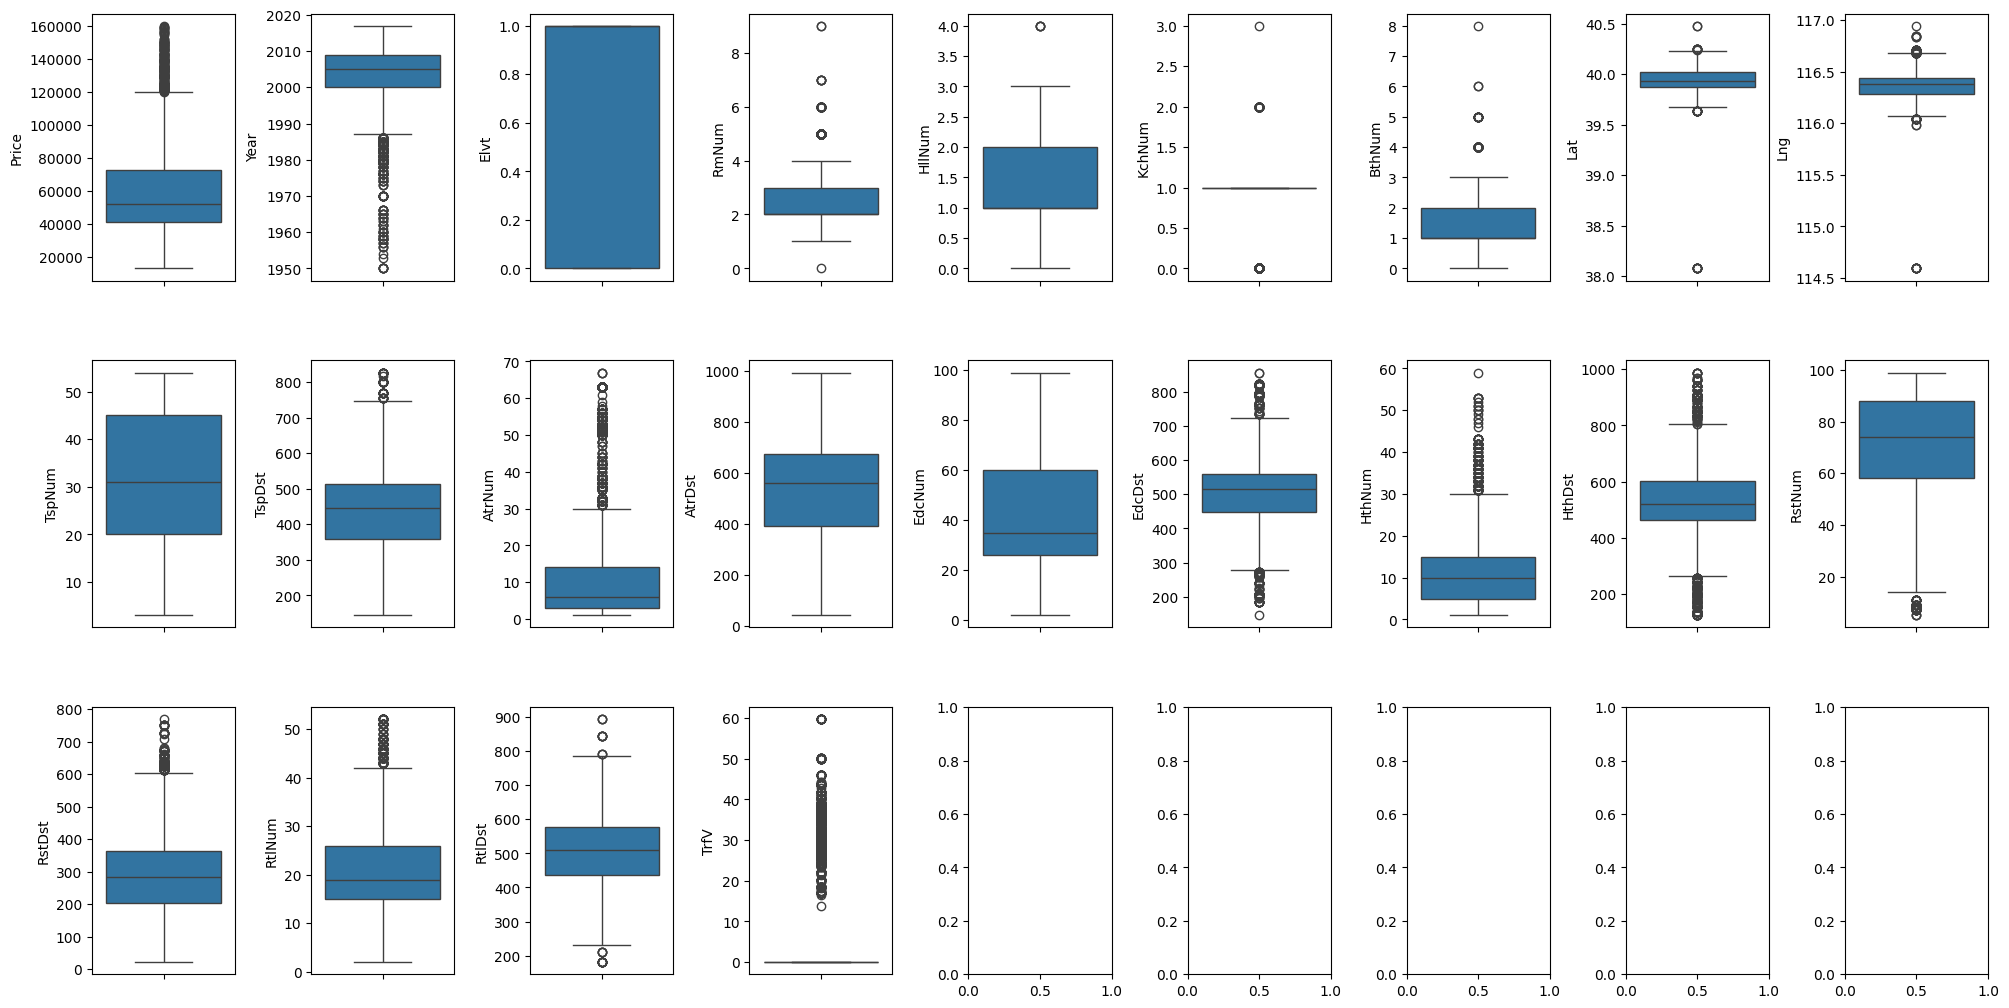

In [13]:
fig, axs = plt.subplots(ncols=9, nrows=3, figsize=(20, 10))
index = 0
axs = axs.flatten()
for k,v in data.items():
    sns.boxplot(y=k, data=data, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [15]:
for k, v in data.items():
    q1 = v.quantile(0.25)
    q3 = v.quantile(0.75)
    irq = q3 - q1
    v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
    perc = np.shape(v_col)[0] * 100.0 / np.shape(data)[0]
    print("Column %s outliers = %.2f%%" % (k, perc))


Column Price outliers = 1.97%
Column Year outliers = 5.04%
Column Elvt outliers = 0.00%
Column RmNum outliers = 1.99%
Column HllNum outliers = 0.04%
Column KchNum outliers = 100.00%
Column BthNum outliers = 0.92%
Column Lat outliers = 0.30%
Column Lng outliers = 3.82%
Column TspNum outliers = 0.00%
Column TspDst outliers = 0.56%
Column AtrNum outliers = 18.39%
Column AtrDst outliers = 0.00%
Column EdcNum outliers = 0.00%
Column EdcDst outliers = 2.33%
Column HthNum outliers = 2.34%
Column HthDst outliers = 4.54%
Column RstNum outliers = 0.64%
Column RstDst outliers = 1.40%
Column RtlNum outliers = 2.82%
Column RtlDst outliers = 0.27%
Column TrfV outliers = 100.00%


<Figure size 640x480 with 0 Axes>

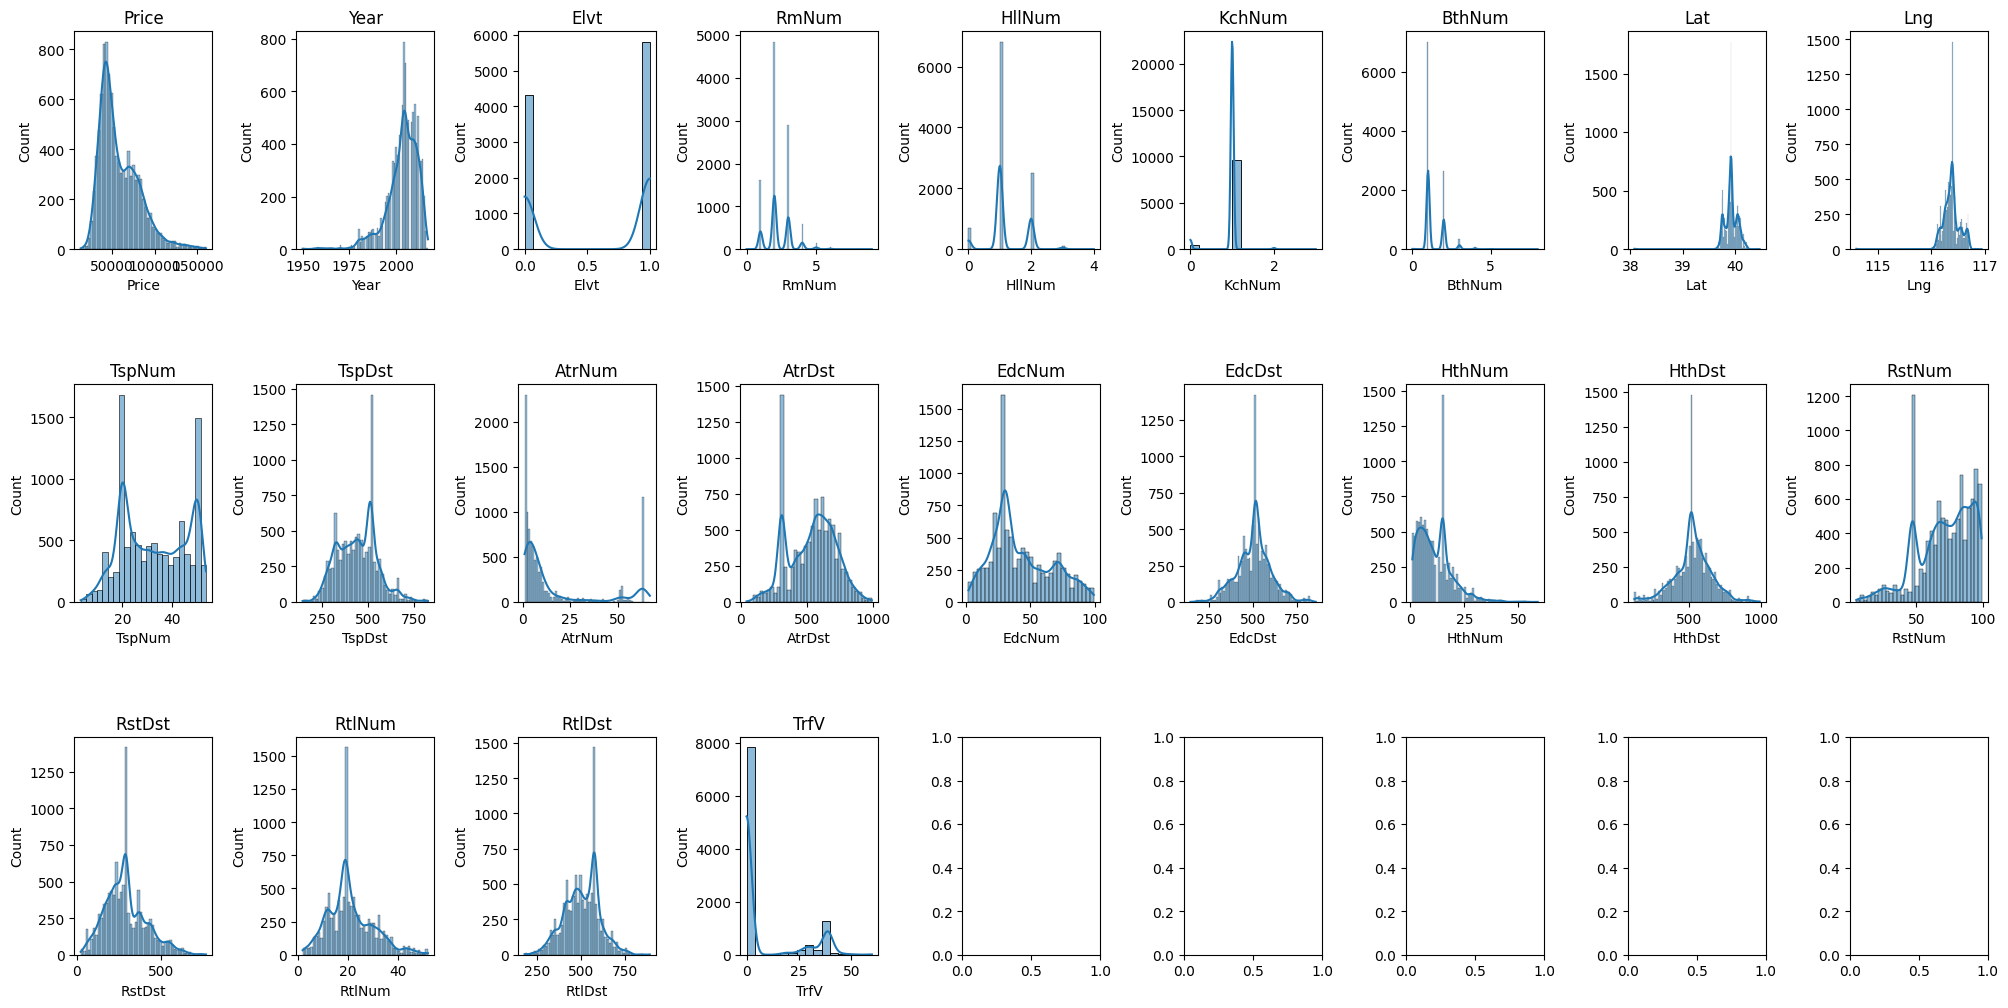

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()
fig, axs = plt.subplots(ncols=9, nrows=3, figsize=(20, 10))
index = 0
axs = axs.flatten()
for k, v in data.items():
    sns.histplot(v, kde=True, ax=axs[index])
    axs[index].set_title(k)
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()


<Figure size 640x480 with 0 Axes>

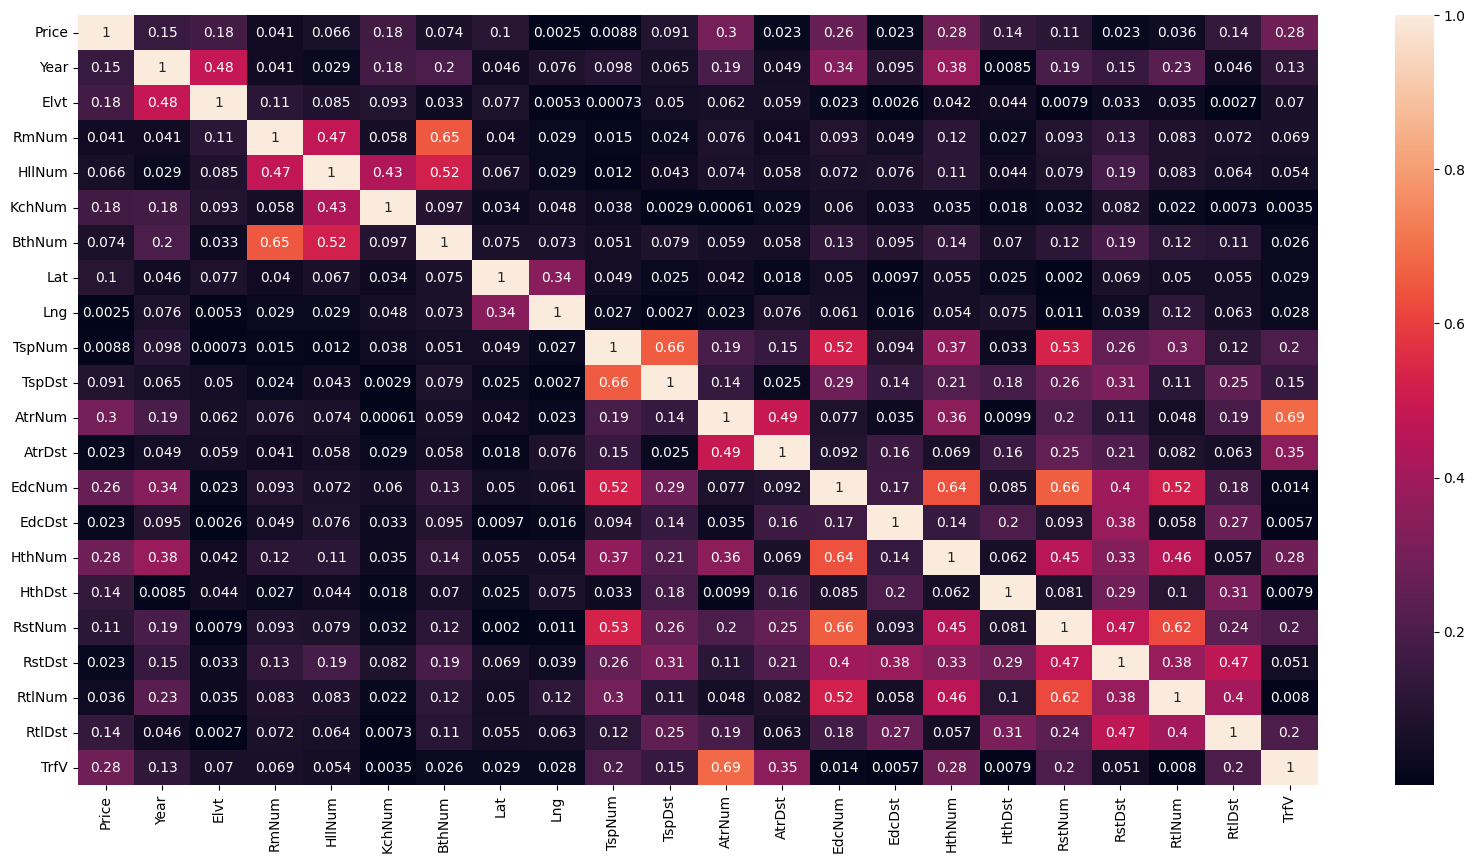

In [16]:
plt.clf()
plt.figure(figsize=(20, 10))
sns.heatmap(data.corr().abs(),  annot=True)
plt.show()

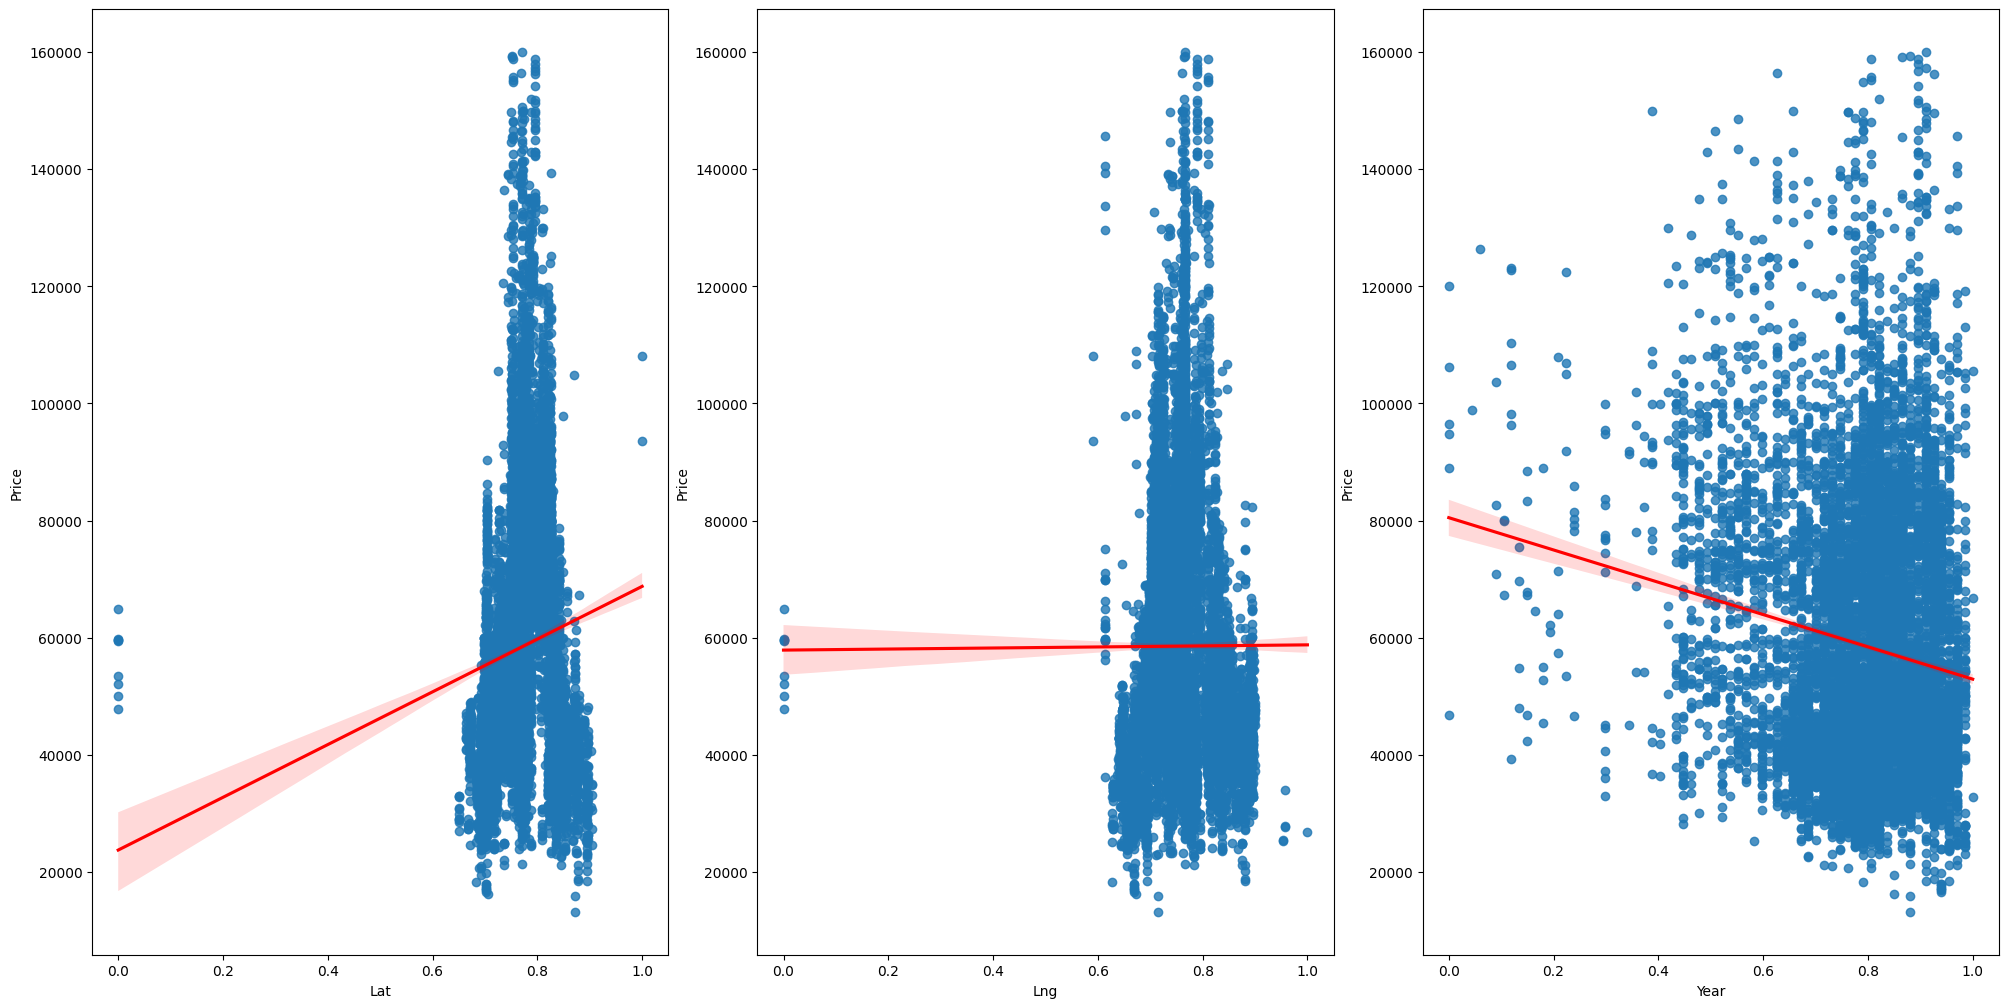

In [17]:
from sklearn import preprocessing
# Let's scale the columns before plotting them against MEDV
min_max_scaler = preprocessing.MinMaxScaler()
# column_sels = ['AtrNum', 'EdcNum', 'HthNum', 'RstNum', 'TrfV', 'DstPct']
column_sels = ['Lat', 'Lng', 'Year']
x = data.loc[:,column_sels]
y = data['Price']
x = pd.DataFrame(data=min_max_scaler.fit_transform(x), columns=column_sels)
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(20, 10))
index = 0
axs = axs.flatten()
for i, k in enumerate(column_sels):
    sns.regplot(y=y, x=x[k], ax=axs[i], line_kws={"color": "red"})
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

Biểu đồ đầu tiên cho thấy giá nhà có xu hướng tăng nhẹ khi giá trị Lat tăng. Điều này có thể gợi ý rằng vị trí địa lý (vĩ độ) có ảnh hưởng đến giá nhà.


Biểu đồ thứ hai cho thấy mối quan hệ giữa Lng và Price gần như không có xu hướng rõ ràng (đường hồi quy gần như phẳng). Điều này có thể chỉ ra rằng kinh độ không ảnh hưởng nhiều đến giá nhà.



Biểu đồ thứ ba cho thấy giá nhà có xu hướng giảm khi giá trị Year tăng. Điều này có thể ám chỉ rằng các ngôi nhà được xây dựng gần đây hơn (năm lớn hơn) có giá thấp hơn, hoặc có thể liên quan đến các yếu tố khác như sự thay đổi trong thị trường bất động sản.

In [18]:
corr = data.corr()
print(corr.shape)

(22, 22)


In [20]:
# Spliting target variable and independent variables
X = data.drop(['Price'], axis = 1)
y = data['Price']

In [ ]:

# Splitting to training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 4)


In [23]:
# Import library for Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa dữ liệu (nếu cần)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Create a Linear regressor
lm = LinearRegression()

# Train the model using the training sets
lm.fit(X_train_scaled, y_train)

# Value of y intercept
print(lm.intercept_)

# Converting the coefficient values to a dataframe
coeffcients = pd.DataFrame([X_train.columns, lm.coef_]).T
coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})
print(coeffcients)

58318.31114245417
   Attribute Coefficients
0       Year -3053.643288
1       Elvt  5529.883941
2      RmNum -1868.983955
3     HllNum   -17.422823
4     KchNum  3129.400163
5     BthNum   3250.80359
6        Lat  2185.207997
7        Lng  -137.896789
8     TspNum -1462.943866
9     TspDst  1100.288027
10    AtrNum  5406.006482
11    AtrDst  3229.374797
12    EdcNum  5236.429961
13    EdcDst   286.604419
14    HthNum   1315.71834
15    HthDst  1065.276094
16    RstNum  3637.601269
17    RstDst  2216.697496
18    RtlNum -4868.978316
19    RtlDst   -524.79936
20      TrfV   2798.49215


In [24]:
# Model prediction on train data
y_pred = lm.predict(X_train)
# Model Evaluation
print('R^2:',metrics.r2_score(y_train, y_pred))
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_train, y_pred))*(len(y_train)-1)/(len(y_train)-X_train.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_train, y_pred))
print('MSE:',metrics.mean_squared_error(y_train, y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_train, y_pred)))


R^2: -11021.135126630401
Adjusted R^2: -11053.883405869115
MAE: 2279152.4062170186
MSE: 5693668972032.77
RMSE: 2386141.020986138


d:\Python_3_10\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


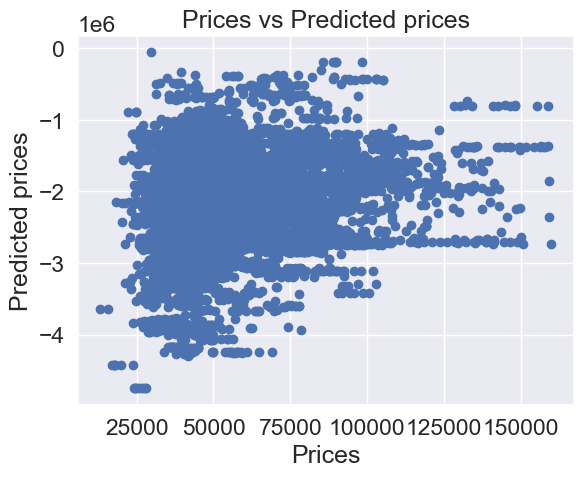

In [25]:
# Visualizing the differences between actual prices and predicted values
plt.clf()
plt.scatter(y_train, y_pred)
plt.xlabel("Prices")
plt.ylabel("Predicted prices")
plt.title("Prices vs Predicted prices")
plt.show()


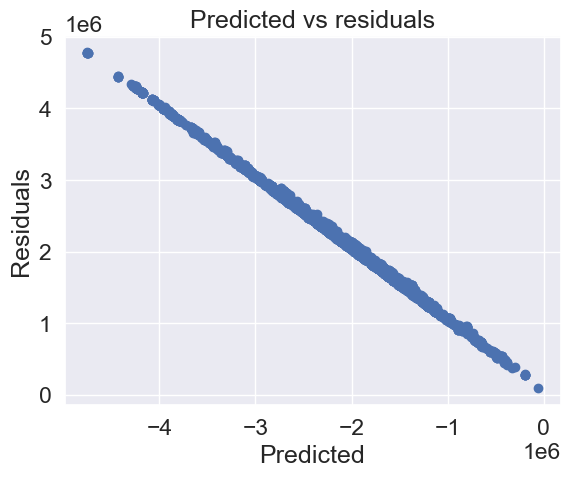

In [26]:
# Checking residuals
plt.clf()
plt.scatter(y_pred,y_train-y_pred)
plt.title("Predicted vs residuals")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


C:\Users\15520\AppData\Local\Temp\ipykernel_18844\3881400528.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train-y_pred)


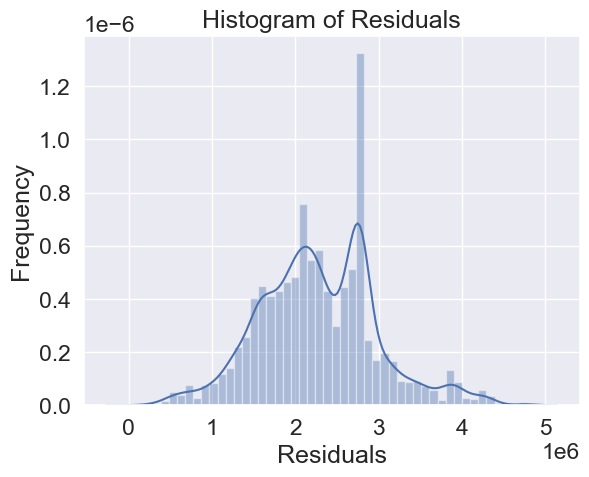

In [27]:
# Checking Normality of errors
plt.clf()
sns.distplot(y_train-y_pred)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [28]:
# Predicting Test data with the model
y_test_pred = lm.predict(X_test)
# Model Evaluation
acc_linreg = metrics.r2_score(y_test, y_test_pred)
mae_linreg = metrics.mean_absolute_error(y_test, y_test_pred)
rmse_linreg = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))
print('R^2:', acc_linreg)
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_test, y_test_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('MAE:',mae_linreg)
print('MSE:',metrics.mean_squared_error(y_test, y_test_pred))
print('RMSE:',rmse_linreg)

R^2: -10336.66808885544
Adjusted R^2: -10408.624015227984
MAE: 2289380.790933395
MSE: 5750081800124.435
RMSE: 2397932.8181007146


d:\Python_3_10\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


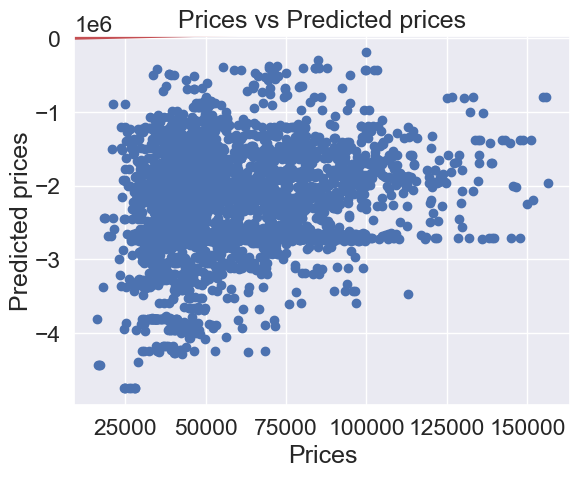

In [29]:
# Visualizing the differences between actual prices and predicted values
plt.clf()
plt.scatter(y_test, y_test_pred)
plt.xlabel("Prices")
plt.ylabel("Predicted prices", labelpad=1.5)
plt.title("Prices vs Predicted prices")
xpoints = ypoints = plt.xlim()
plt.plot(xpoints, ypoints, linestyle='-', color='r', lw=3, scalex=False, scaley=False)
plt.show()

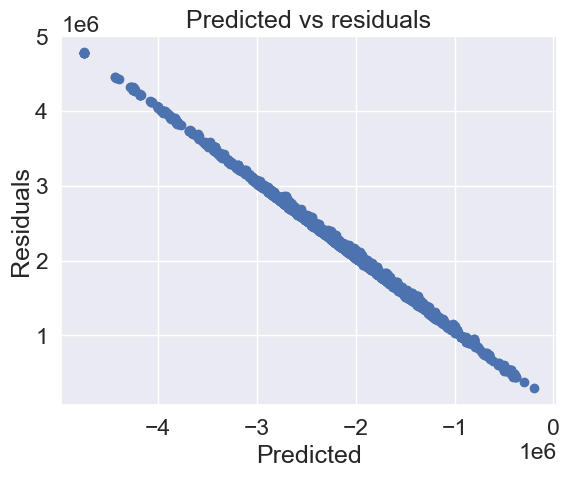

In [30]:
# Checking residuals
plt.clf()
plt.scatter(y_test_pred,y_test-y_test_pred)
plt.title("Predicted vs residuals")
plt.xlabel("Predicted")
plt.ylabel("Residuals", labelpad=1.5)
plt.show()

C:\Users\15520\AppData\Local\Temp\ipykernel_18844\1891131566.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_test_pred)


<function matplotlib.pyplot.show(close=None, block=None)>

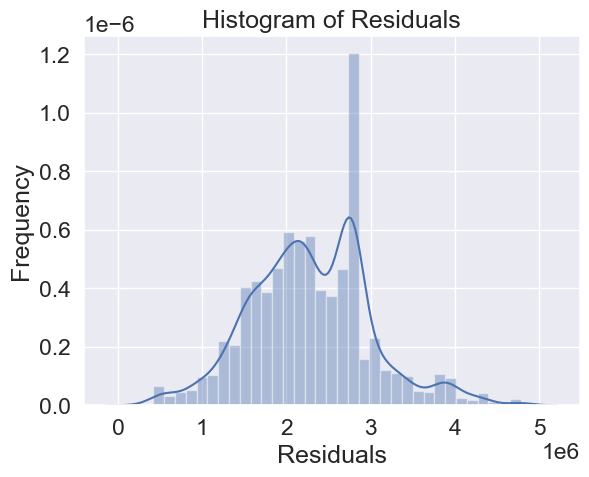

In [31]:
# Checking Normality of errors
plt.clf()
sns.distplot(y_test-y_test_pred)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show